In [ ]:
import sys
from packaging import version
import sklearn

# 노트북이 코랩에서 실행 중인지 체크합니다.
if 'google.colab' in sys.modules:
    !echo 'debconf debconf/frontend select Noninteractive' | debconf-set-selections
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

    # 나눔바른고딕 폰트로 설정합니다.
    import matplotlib.pyplot as plt
    plt.rc('font', family='NanumBarunGothic')
    # 마이너스 기호 표시 오류 수정
    import matplotlib
    matplotlib.rcParams['axes.unicode_minus'] = False

assert sys.version_info >= (3, 7)

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_4817/266164749.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [ ]:
# 데이터는 판다스에서 2차원 형태의 DataFrame 으로 나타난다.
# 하나의 열은 Series, 1차원 형태의 배열과 같은 데이터 구조이다.

# 데이터의 구조 확인

housing.info()

housing["ocean_proximity"].value_counts()

housing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


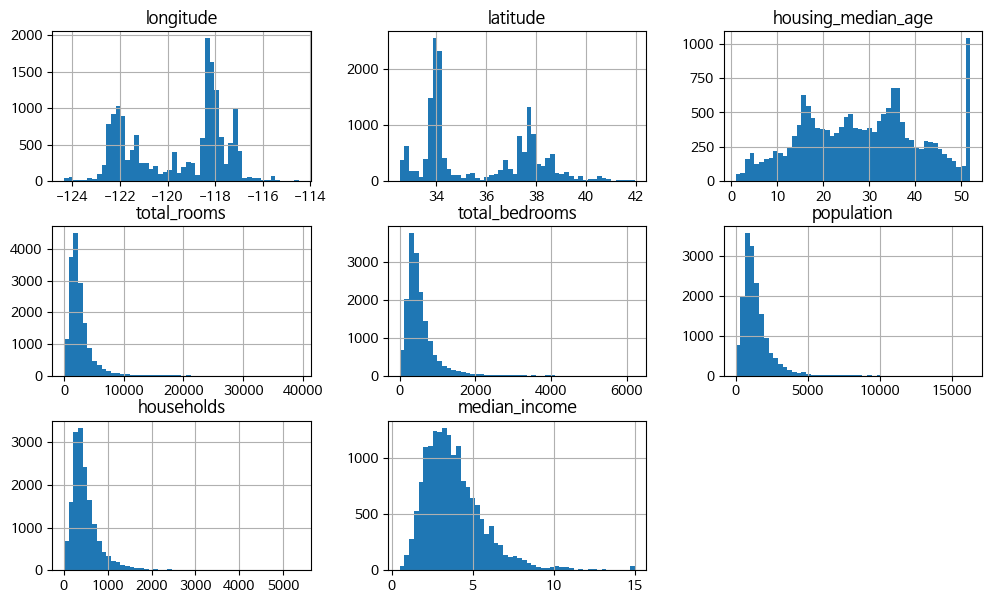

In [47]:
# 데이터의 시각화

housing.hist(bins=50, figsize=(12, 7))
plt.show()

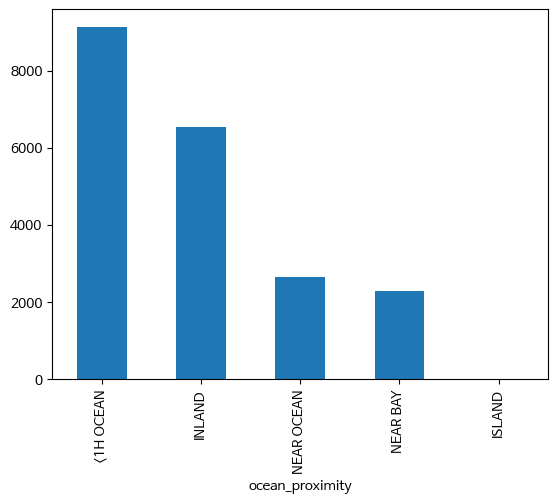

In [ ]:
# 범주형 특성의 시각화

housing["ocean_proximity"].value_counts().plot(kind="bar")

plt.show()

In [ ]:
import numpy as np

np.random.seed(42)

def shuffle_and_split_data(data, test_ratio):
    # 샘플의 개수 인덱스를 무작위로 섞은 리스트 생성
    shuffled_indices = np.random.permutation(len(data))
    # 비율 만큼의 테스트 세트 샘플 개수 설정
    test_set_size = int(len(data) * test_ratio)
    # 무작위 인덱스를 개수만큼 자르기
    test_indices = shuffled_indices[:test_set_size]
    # 나머지는 훈련 세트 샘플
    train_indices = shuffled_indices[test_set_size:]
    #
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = shuffle_and_split_data(housing, 0.2)

print(f"훈련 세트의 샘플 개수 : {len(train_set)}")
print(f"테스트 세트의 샘플 개수 : {len(test_set)}")

훈련 세트의 샘플 개수 : 16512
테스트 세트의 샘플 개수 : 4128


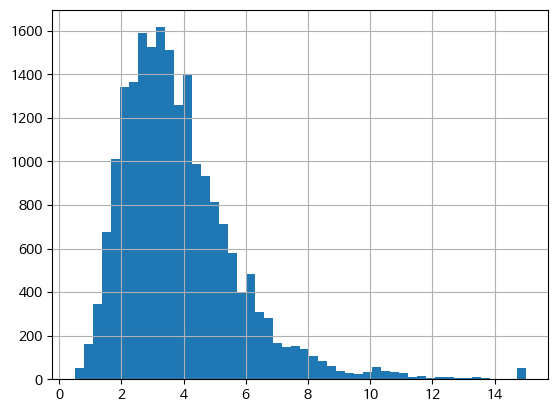

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64


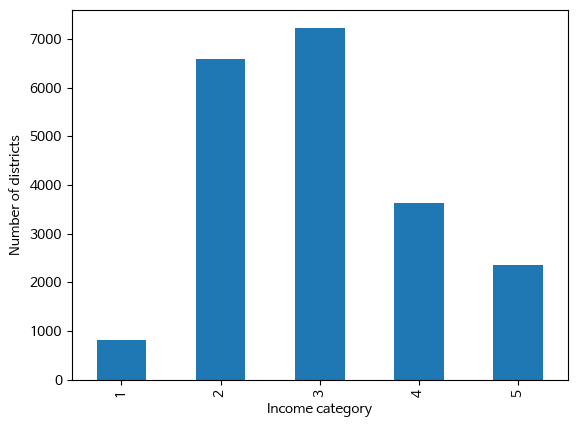

In [ ]:
# 계층적 샘플링

# 예측하고자 하는 주택의 중앙값에서 중간 소득이 중요한 특성이라면, 훈련 세트와 테스트 세트에서도
# 이 특성의 분포대로 잘 나누어져 있어야 정확한 학습이 가능하다.

housing["median_income"].hist(bins=50)

plt.show()

# 그래프를 확인해보면, 주로 소득이 1.5에서 6사이에 몰려있는데, 이를 범주형 특성으로 바꾼 특성을 추가해보자.

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

print(housing["income_cat"].value_counts())

housing["income_cat"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()


In [ ]:
# 계층적 샘플링을 위한 도구

from sklearn.model_selection import StratifiedShuffleSplit

# split 횟수를 10번으로 지정하여 계층적 샘플링을 10번 진행한다. 결과물은 10쌍의 계층적 샘플링으로 나뉜 훈련, 테스트 세트이다.
# 여러개로 나누어서 실제 데이터의 분포와 유사한지 교차 검증을 진행해 볼 수 있다.
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []

for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

# 현재 코드에서는 교차 검증 없이 첫번째 쌍을 사용한다.
# strat_train_set_0, strat_test_set_0 = strat_splits[0]
strat_train_set_0 = strat_splits[0][0].copy()
strat_test_set_0 = strat_splits[0][1].copy()

# 계층적 샘플링을 진행한 세트
print(strat_train_set_0["income_cat"].value_counts() / len(strat_train_set_0))

# 실제 데이터 세트
print(housing["income_cat"].value_counts() / len(housing))

# 더 간단한 방법으로는 이것을 사용할 수 있다.
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)



def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    # 실제 데이터 분포
    "Overall %": income_cat_proportions(housing),
    # 계층적 샘플링 데이터 분포
    "Stratified %": income_cat_proportions(strat_test_set_0),
    # 무작위 샘플링 데이터 분포
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

for set_ in (strat_train_set_0, strat_test_set_0):
    set_.drop("income_cat", axis=1, inplace=True)

strat_train_set_0.info()



income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB


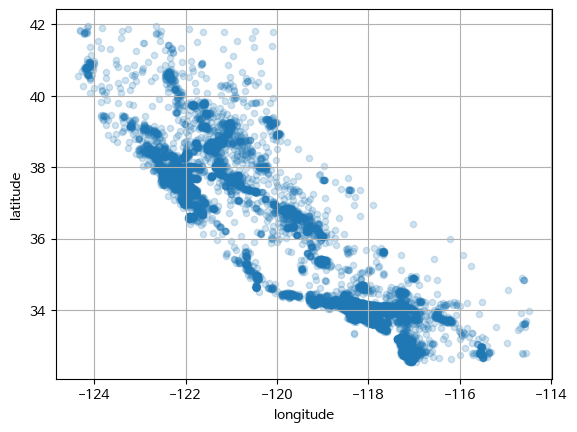

In [ ]:
# 데이터 시각화

housing = strat_train_set_0.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()


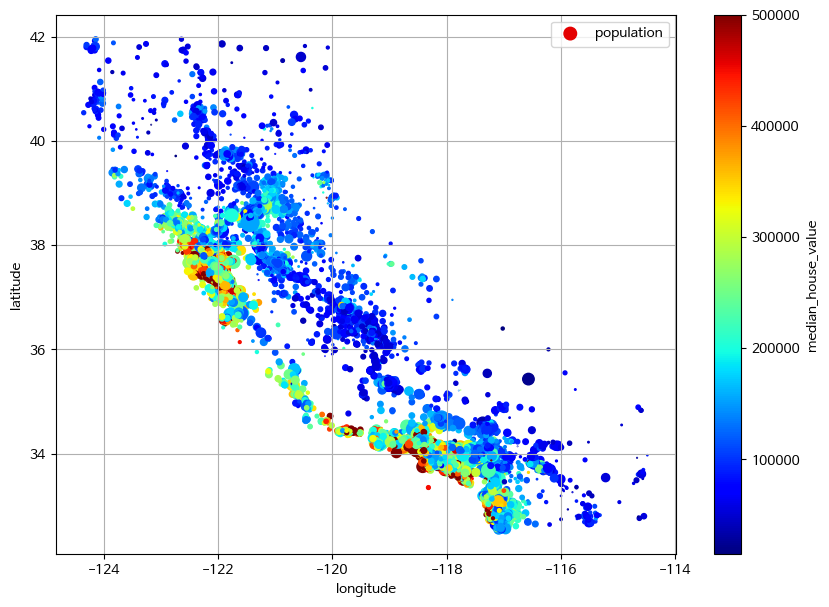

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, figsize=(10, 7))

plt.show()

In [ ]:
# 상관관계 파악
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


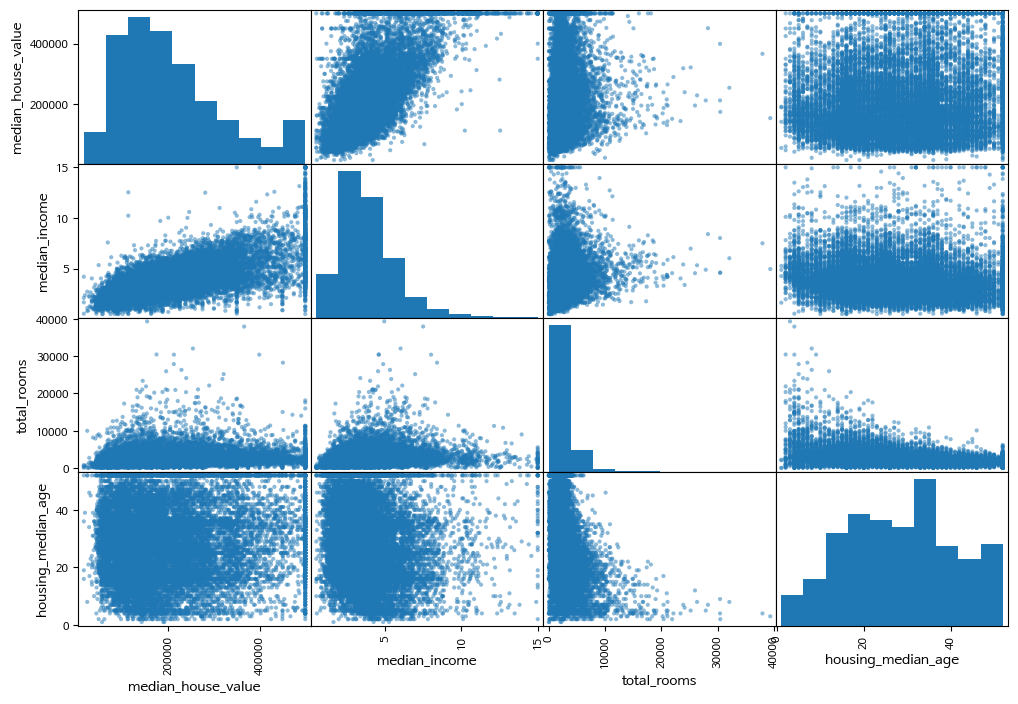

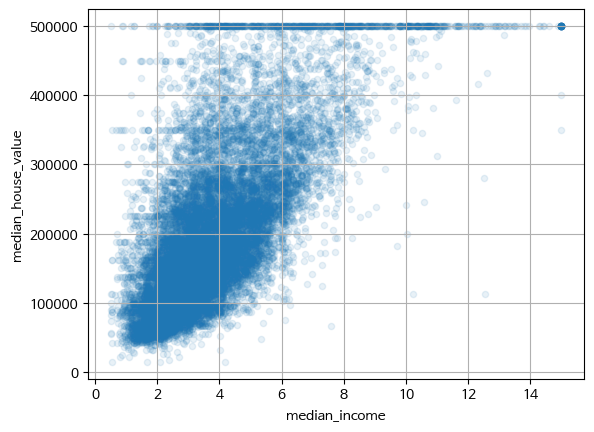

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

plt.show()

housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)

plt.show()

In [ ]:
# 특성 조합

housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

# 새롭게 조합된 특성의 상관관계 확인
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


In [ ]:
housing = strat_train_set_0.drop("median_house_value", axis=1)
housing_labels = strat_train_set_0["median_house_value"].copy()

# 결측치를 포함한 샘플 행 제거
# housing.dropna(subset=["total_bedrooms"], inplace=True)    # 옵션 1

# 결측치를 가지는 특성 제거
# housing.drop("total_bedrooms", axis=1)                     # 옵션 2

# 특성의 중간값으로 결측치 채우기
# median = housing["total_bedrooms"].median()                # 옵션 3
# housing["total_bedrooms"].fillna(median, inplace=True)

In [ ]:
from sklearn.impute import SimpleImputer

null_rows_idx = housing.isnull().any(axis=1)
print(housing.loc[null_rows_idx].head())

# 중간값을 선택
imputer = SimpleImputer(strategy="median")

# 수치형 특성만 가능
housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)

imputer.statistics_

housing_num.median().values

X = imputer.transform(housing_num)
imputer.feature_names_in_

housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

print(housing_tr.loc[null_rows_idx].head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14452    -120.67     40.50                15.0       5343.0             NaN   
18217    -117.96     34.03                35.0       2093.0             NaN   
11889    -118.05     34.04                33.0       1348.0             NaN   
20325    -118.88     34.17                15.0       4260.0             NaN   
14360    -117.87     33.62                 8.0       1266.0             NaN   

       population  households  median_income ocean_proximity  
14452      2503.0       902.0         3.5962          INLAND  
18217      1755.0       403.0         3.4115       <1H OCEAN  
11889      1098.0       257.0         4.2917       <1H OCEAN  
20325      1701.0       669.0         5.1033       <1H OCEAN  
14360       375.0       183.0         9.8020       <1H OCEAN  
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14452    -120.67     40.50                15.0       5343.0         

In [37]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

from sklearn.preprocessing import OrdinalEncoder

# 순서를 가지는 수치형 데이터로 변환
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

# 범주형 특성의 카테고리 반환
ordinal_encoder.categories_
# 예시로, 범주형 특성의 값이 숫자로 치환된 것을 알 수 있다.
# print(housing_cat_encoded)

# 그러나, 머신러닝의 알고리즘이 수치형 데이터를 보고 범주형 특성 간의 관계를 찾고자 할 수 있다.
# 만약 성적 등급과 같이 순서가 의미가 있는 범주형 데이터의 경우 괜찮을 수 있으나
# 현재와 같은 경우에는 일반적으로 카테고리별 이전 특성을 만들어 해결한다.

# OneHotEncoder를 통해 해당 카테고리를 1로, 나머지는 0으로 하는 희소 행렬로 표현한다.
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# 판다스에도 범주형 특성을 이진 특성으로 바꾸는 get_dummies() 함수가 있다.
# 그러나 이것은 아래와 같이 두 개의 카테고리만을 보았기 때문에 당연히 2개만 표시된다.
# 만약 이외의 새로운 카테고리가 추가되면, 에러가 발생하지는 않으나 카테고리 열의 순서가 바뀌는 등
# 일관성이 없이 학습에서 문제를 일으킬 가능성이 있다.
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

# 원-핫 인코더는 훈련 세트에 대한 fit()을 통해 미리 훈련 세트의 카테고리를 기억할 수 있기 때문에,
# 새로운 카테고리가 나타나면, 무시하거나(0 으로 표기), 에러를 발생시킬 수 있다.
cat_encoder.transform(df_test).toarray()

df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

cat_encoder.handle_unknown = "ignore"
# 기존의 카테고리 ISLAND 은 0 0 1 0 0 과 같이 정상적으로 처리되었으나
# 임의의 새로운 카테고리 <2H OCEAN 은 0 0 0 0 0 으로 처리됨을 알 수 있다.
cat_encoder.transform(df_test_unknown).toarray()

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

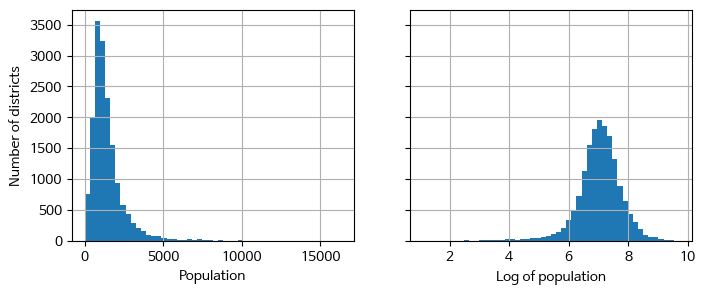

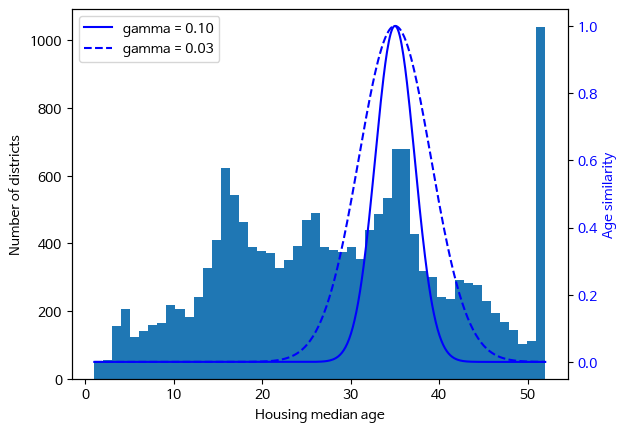

In [41]:
# 특성 스케일링

# min-max 스케일링
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

# 정규화
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

# 주로 min-max는 범위가 일정하게 정해진 경우, 정규화는 범위가 일정치 않은 경우 사용할 수 있다.
# min-max의 경우 min 또는 max에 가까운 이상치에 대해 나머지 값들이 한 쪽에 몰려있는 문제가 있지만
# 정규화는 평균과 표준편차를 기준으로 하여 이상치가 있더라도 정상치 사이의 거리 비율을 유지하여 나타낼 수 있다.

# 그러나 일반적으로 특성의 분포가 한 쪽으로 치우쳐진 멱법칙 분포를 따를 경우, 로그 변환을 통해 종 모양의 가우스 분포에 가깝게 나타낼 수 있다.
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
plt.show()

# 또한 분포를 카테고리로 잘라 나타내어 히스토그램화하는 버킷타이징을 생각해 볼 수 있다.
# 선형 회귀와 같은 알고리즘에서는 봉우리가 하나인 유니모달이 학습에 있어 유리한데, 버킷타이징 후
# 방사 기저 함수, 가우스 RBF를 통해 특정 값과 데이터의 거리를 나타내어 가우스 분포의 형태로 나타낼 수 있다.

from sklearn.metrics.pairwise import rbf_kernel

# 35년을 기준으로 설정, 감마 값은 0.1
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)

# 감마 값에 따른 변화 확인
# 감마 값이 클수록 더 정확하게 잡아내나, 너무 높다면 이 특성에만 치우쳐져 과대적합
# 감마 값이 작을수록 유연하게 처리하나, 너무 낮다면 데이터 간 차별점이 드러나지 않아 학습이 어려워 과소적합
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # x축을 공유 하는 쌍둥이 축을 만듭니다
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
plt.show()

In [46]:
from sklearn.linear_model import LinearRegression

# 스케일링으로 정규화를 선택
target_scaler = StandardScaler()
# housing_labels.to_frame()은 예측하고자 하는 레이블, 즉 중간 주택 가격을 의미
# 레이블을 정규화
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

# 스케일링된 레이블로 선형 회귀 모델을 훈련
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)

# 새 데이터를 가정
some_new_data = housing[["median_income"]].iloc[:5]

# 예측값은 원본 스케일이 아닌 변환된 스케일이므로 inverse_transform() 으로 원본 스케일로 되돌린다.
scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

# TransformedTargetRegressor 에서는 스케일링된 레이블이 아닌 원본 레이블을 사용하여 훈련 세트로 훈련한다.
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

print(predictions)

[[131997.15275877]
 [299359.35844434]
 [146023.37185694]
 [138840.33653057]
 [192016.61557639]]
[131997.15275877 299359.35844434 146023.37185694 138840.33653057
 192016.61557639]
